# dLEM: train shallow, extrapolate far

This notebook demonstrates two properties of the full-rollout engine that make it cheap to
reach large genomic distances:

1. **Extrapolation is (almost) free.** Training `full_rollout_selfnorm` (the trainable,
   self-normalizing rollout `dlem.fit` uses) scales with `train_to`. But once `L`/`R` are
   fit, `fit.predict(rows)` for `rows > train_to` calls the plain, non-trainable
   `full_rollout` -- no gradients, no Adam state, no checkpointing -- which is dramatically
   cheaper. Below, extrapolating a shallow (`train_to=100`) fit out to the full 7 Mb window
   costs a small fraction of what training that deep directly would.
2. **The extrapolation is accurate, and the barrier profile is resolution-independent.**
   We validate the shallow-fit-then-extrapolate shortcut against a directly-trained
   "ground truth" fit at the same depth, and separately confirm that `L`/`R` come out
   nearly identical at 1kb and 10kb resolution when the `s` slowdown constant is rescaled
   proportionally to bin size (`s=0.025` @10kb &harr; `s=0.0025` @1kb).

**Data**: the same H1-hESC window as `quick_start.ipynb` (chr10:19-26 Mb, `4DNFI9GMP2J8`),
loaded at both 10kb (`data/example_chr10.cool`, 700 bins) and 1kb
(`data/example_chr10_1kb.cool`, 7000 bins, see `data/create_example_data_1kb.py`).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from IPython.display import display

import dlem
from dlem.viz import band_to_dense, _resolve_cmap

print('dlem loaded from:', dlem.__file__)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


dlem loaded from: /home/tis97/dlem/dlem/__init__.py


## 1. Load both bands

Same 7 Mb window (chr10:19-26 Mb), at 10kb (700 bins) and 1kb (7000 bins).

In [2]:
CHROM = "ref_region"
GENOMIC_OFFSET_BP = int(19.0 * 1e6)   # bin 0 -> chr10:19,000,000

band_10kb = dlem.load_band("data/example_chr10.cool", resolution=10_000, chrom=CHROM, width=700)
band_1kb = dlem.load_band("data/example_chr10_1kb.cool", resolution=1_000, chrom=CHROM, width=7000)
print(f"10kb band: {band_10kb.shape}   1kb band: {band_1kb.shape}")

[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_10000_700_1241ac6cc9d0dcc8.npy
[band] cache hit /home/tis97/dlem/band_cache/band_ref_region_1000_7000_2aefc535c46a0cf9.npy
10kb band: (700, 700)   1kb band: (7000, 7000)


## 2. Fit three models

- **10kb shallow**: `train_to=100` (1 Mb) -- the fit we'll extrapolate from.
- **10kb ground truth**: `train_to=700` (the full 7 Mb window) -- trained directly to full
  depth, used only to validate the extrapolation below (not itself a recommended
  workflow -- it's only this cheap because the window is tiny; see the `dlemFR_eval`
  whole-chromosome stress test for where direct full-depth training stops being cheap).
- **1kb shallow**: `train_to=1000` (1 Mb, matching the 10kb shallow fit's physical depth),
  with `s` rescaled 10x finer (`0.0025`) to match the established resolution convention.

In [3]:
t0 = time.time()
fit_10kb_shallow = dlem.fit(band_10kb, s=0.025, train_to=100, n_opt=1500, verbose=False)
t_shallow_10kb = time.time() - t0

t0 = time.time()
fit_10kb_deep = dlem.fit(band_10kb, s=0.025, train_to=700, n_opt=1500, verbose=False)
t_deep_10kb = time.time() - t0

t0 = time.time()
fit_1kb_shallow = dlem.fit(band_1kb, s=0.0025, train_to=1000, n_opt=1500, verbose=False)
t_shallow_1kb = time.time() - t0

print(f"10kb shallow (train_to=100):  {t_shallow_10kb:.1f}s   mse={fit_10kb_shallow.mse:.4f}  corr={fit_10kb_shallow.corr:.4f}")
print(f"10kb deep    (train_to=700):  {t_deep_10kb:.1f}s   mse={fit_10kb_deep.mse:.4f}  corr={fit_10kb_deep.corr:.4f}")
print(f"1kb shallow  (train_to=1000): {t_shallow_1kb:.1f}s   mse={fit_1kb_shallow.mse:.4f}  corr={fit_1kb_shallow.corr:.4f}")

10kb shallow (train_to=100):  12.2s   mse=0.1156  corr=0.8365
10kb deep    (train_to=700):  46.0s   mse=0.1994  corr=0.5216
1kb shallow  (train_to=1000): 89.0s   mse=0.1663  corr=0.7701


`mse`/`corr` here are aggregate deployment-fit metrics averaged across *all* trained
diagonals, so they aren't directly comparable across different `train_to` values: the
10kb "ground truth" fit's `corr` looks worse than the shallow fit's not because anything
went wrong, but because it must also jointly fit the far-distance diagonals -- which are
inherently noisier and harder for a two-parameter (`L`,`R`) model to capture (the same
long-range "broad-domain gap" the `dlemFR_eval` stress test found). What matters for the
validation below is not this aggregate number but whether the two fits' `L`/`R` *barrier
profiles* agree -- which section 5 checks directly.

## 3. Extrapolate

`fit.predict(rows)` with `rows > train_to` reuses the fit `L`/`R` in the plain (inference-
only) `full_rollout` -- no re-optimization. Compare the time this takes against the
training times above.

In [4]:
t0 = time.time()
pred_10kb_extrap = fit_10kb_shallow.predict(700)
t_extrap_10kb = time.time() - t0

t0 = time.time()
pred_1kb_extrap = fit_1kb_shallow.predict(7000)
t_extrap_1kb = time.time() - t0

print(f"10kb: extrapolating 100 -> 700 rows took {t_extrap_10kb:.2f}s  "
      f"(training to 700 directly took {t_deep_10kb:.1f}s)")
print(f"1kb:  extrapolating 1000 -> 7000 rows took {t_extrap_1kb:.2f}s  "
      f"(training that deep directly was never attempted here -- "
      f"the whole-chromosome stress test found it OOMs on a 24.5GB GPU well before 7000 rows)")

10kb: extrapolating 100 -> 700 rows took 0.01s  (training to 700 directly took 46.0s)
1kb:  extrapolating 1000 -> 7000 rows took 0.49s  (training that deep directly was never attempted here -- the whole-chromosome stress test found it OOMs on a 24.5GB GPU well before 7000 rows)


## 4. Patch visualization

Same double-triangle convention as `quick_start.ipynb`: data O/E upper triangle, model O/E
lower triangle, `L` (blue) above, `R` (orange) to the right. The dashed line marks
`train_to=100` -- everything below/left of it is genuinely trained, everything above/right
is the 10kb shallow fit extrapolating past what it optimized on.

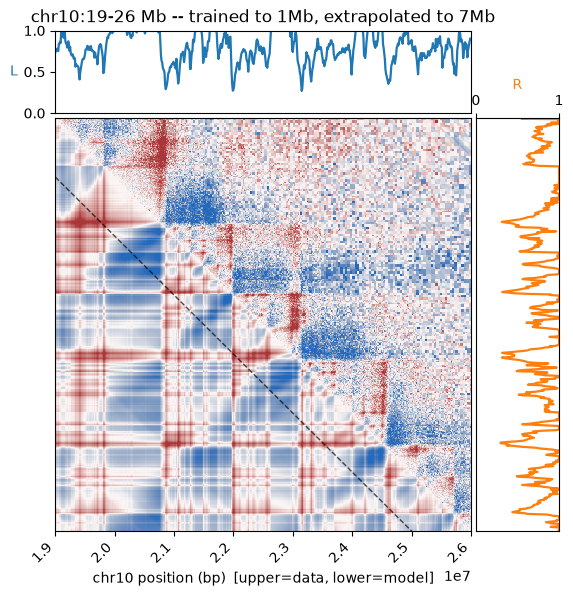

In [5]:
def plot_example_patch(fit, band, start, span, res, chrom, label, *, checkpoint=None,
                  out=None, seam_row=None, offset_bp=0):
    """seam_row: if given (e.g. fit.train_to when span > fit.train_to), draws a dashed
    guide line in the model (lower) triangle marking the genomic distance beyond which the
    full rollout is extrapolating past what was actually optimized."""
    L, R = fit._LR(checkpoint)

    data_oe_band = dlem.normalize_oe(band)
    model_oe_band = dlem.normalize_oe(fit.predict(span, checkpoint=checkpoint))

    data_dense = band_to_dense(np.asarray(data_oe_band), start, start + span)
    model_dense = band_to_dense(np.asarray(model_oe_band), start, start + span)
    patch = np.triu(data_dense) + np.tril(model_dense, k=-1)

    v = float(np.nanpercentile(np.abs(patch[np.isfinite(patch)]), 98)) or 1.0

    start_coor, end_coor = offset_bp + start * res, offset_bp + (start + span) * res
    coords = offset_bp + np.arange(start, start + span) * res

    fig = plt.figure(figsize=(6.5, 6.5))
    gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.02, hspace=0.02,
                           height_ratios=[1, 5], width_ratios=[5, 1])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

    ax_main.imshow(patch, extent=[start_coor, end_coor, end_coor, start_coor],
                  cmap=_resolve_cmap("vlag"), vmin=-v, vmax=v, aspect="auto",
                  interpolation="none")
    ax_main.set_xlabel(f"{chrom} position (bp)  [upper=data, lower=model]")
    ax_main.tick_params(labelleft=False, left=False)
    plt.setp(ax_main.get_xticklabels(), rotation=45, ha="right")

    ax_top.plot(coords, np.asarray(L)[start:start + span], lw=1.6, color="tab:blue")
    ax_top.set_ylim(0, 1)
    ax_top.set_ylabel("L", rotation=0, ha="right", va="center", color="tab:blue")
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_top.set_title(label)

    ax_right.plot(np.asarray(R)[start:start + span], coords, lw=1.6, color="tab:orange")
    ax_right.set_xlim(0, 1)
    ax_right.set_xlabel("R", color="tab:orange")
    ax_right.xaxis.set_label_position("top")
    ax_right.tick_params(labelleft=False, left=False, labeltop=True, top=True,
                         labelbottom=False, bottom=False)

    if seam_row is not None and seam_row < span:
        seam_bp = seam_row * res
        xs = np.array([start_coor, end_coor])
        ax_main.plot(xs, xs + seam_bp, color="k", lw=1.0, ls="--", alpha=0.7)
        ax_main.set_xlim(start_coor, end_coor)
        ax_main.set_ylim(end_coor, start_coor)

    if out:
        fig.savefig(out, dpi=150, bbox_inches="tight")
    return fig


fig = plot_example_patch(fit_10kb_shallow, band_10kb, 0, 700, 10_000, "chr10",
                    "chr10:19-26 Mb -- trained to 1Mb, extrapolated to 7Mb",
                    seam_row=100, offset_bp=GENOMIC_OFFSET_BP,
                    out="train_shallow_extrapolate_patch.png")
display(fig)
plt.close(fig)

## 5. Validation A: extrapolation accuracy

`L`/`R` from the 10kb shallow fit, extrapolated to 700 rows, vs. `L`/`R` from the 10kb
ground-truth fit trained directly to 700 rows. Both overlaid on the same genomic-position
axis. There is no `train_to` seam marker on this plot: `train_to` bounds the
*distance-from-diagonal* dimension of the band (how far off-diagonal the rollout was
fit/self-normalized), not genomic position -- `L`/`R` are single per-bin values across the
whole window, and nothing about them is tied to a specific genomic-position boundary. That
seam only has meaning in the 2D patch view above, where the axes literally are
distance-from-diagonal.

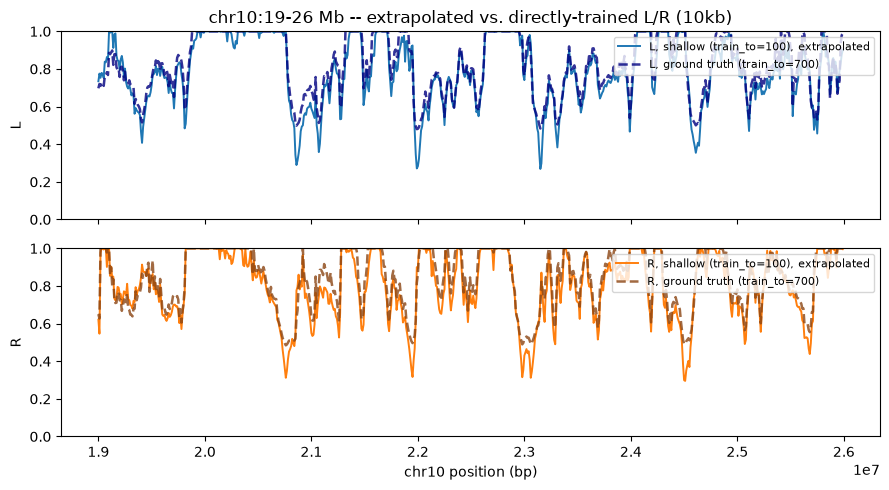

corr(L_extrap, L_ground_truth) = 0.9676
corr(R_extrap, R_ground_truth) = 0.9709


In [6]:
L_shallow, R_shallow = np.asarray(fit_10kb_shallow.L), np.asarray(fit_10kb_shallow.R)
L_deep, R_deep = np.asarray(fit_10kb_deep.L), np.asarray(fit_10kb_deep.R)

coords_10kb = GENOMIC_OFFSET_BP + np.arange(700) * 10_000

fig, (ax_L, ax_R) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax_L.plot(coords_10kb, L_shallow, lw=1.4, color="tab:blue", label="L, shallow (train_to=100), extrapolated")
ax_L.plot(coords_10kb, L_deep, lw=1.8, color="navy", ls="--", alpha=0.8, label="L, ground truth (train_to=700)")
ax_L.set_ylabel("L"); ax_L.set_ylim(0, 1)
ax_L.legend(loc="upper right", fontsize=8)
ax_L.set_title("chr10:19-26 Mb -- extrapolated vs. directly-trained L/R (10kb)")

ax_R.plot(coords_10kb, R_shallow, lw=1.4, color="tab:orange", label="R, shallow (train_to=100), extrapolated")
ax_R.plot(coords_10kb, R_deep, lw=1.8, color="saddlebrown", ls="--", alpha=0.8, label="R, ground truth (train_to=700)")
ax_R.set_ylabel("R"); ax_R.set_ylim(0, 1)
ax_R.set_xlabel("chr10 position (bp)")
ax_R.legend(loc="upper right", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

print(f"corr(L_extrap, L_ground_truth) = {np.corrcoef(L_shallow, L_deep)[0,1]:.4f}")
print(f"corr(R_extrap, R_ground_truth) = {np.corrcoef(R_shallow, R_deep)[0,1]:.4f}")

## 6. Validation B: resolution consistency

`L`/`R` from the 1kb shallow fit vs. the 10kb shallow fit, same window, same physical
training depth (1 Mb). As in section 5, there is no `train_to` marker here for the same
reason -- these are per-bin tracks along genomic position, and `train_to` doesn't live on
that axis.

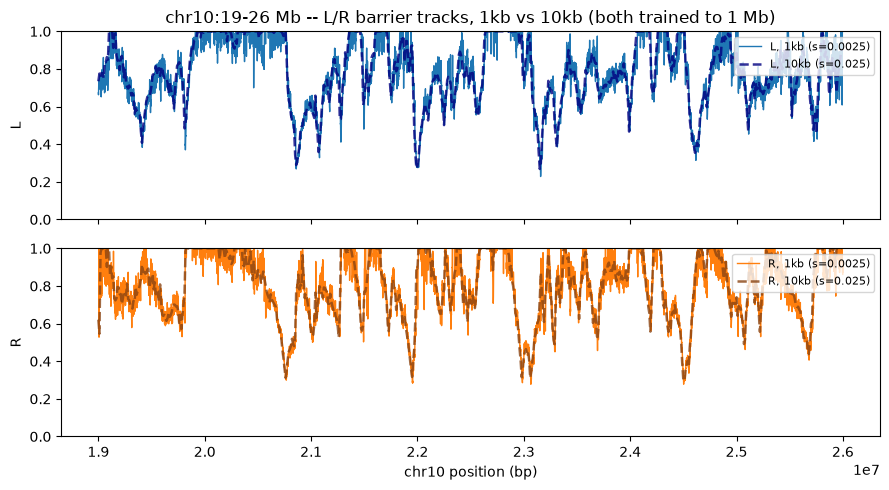

corr(L_1kb_downsampled, L_10kb) = 0.9842
corr(R_1kb_downsampled, R_10kb) = 0.9767


In [7]:
L_1kb, R_1kb = np.asarray(fit_1kb_shallow.L), np.asarray(fit_1kb_shallow.R)
coords_1kb = GENOMIC_OFFSET_BP + np.arange(7000) * 1_000

fig, (ax_L, ax_R) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax_L.plot(coords_1kb, L_1kb, lw=1.0, color="tab:blue", label="L, 1kb (s=0.0025)")
ax_L.plot(coords_10kb, L_shallow, lw=1.8, color="navy", ls="--", alpha=0.8, label="L, 10kb (s=0.025)")
ax_L.set_ylabel("L"); ax_L.set_ylim(0, 1)
ax_L.legend(loc="upper right", fontsize=8)
ax_L.set_title("chr10:19-26 Mb -- L/R barrier tracks, 1kb vs 10kb (both trained to 1 Mb)")

ax_R.plot(coords_1kb, R_1kb, lw=1.0, color="tab:orange", label="R, 1kb (s=0.0025)")
ax_R.plot(coords_10kb, R_shallow, lw=1.8, color="saddlebrown", ls="--", alpha=0.8, label="R, 10kb (s=0.025)")
ax_R.set_ylabel("R"); ax_R.set_ylim(0, 1)
ax_R.set_xlabel("chr10 position (bp)")
ax_R.legend(loc="upper right", fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)

# Compare at 10kb granularity (downsample the 1kb track by averaging every 10 bins)
L_1kb_ds = L_1kb.reshape(700, 10).mean(axis=1)
R_1kb_ds = R_1kb.reshape(700, 10).mean(axis=1)
print(f"corr(L_1kb_downsampled, L_10kb) = {np.corrcoef(L_1kb_ds, L_shallow)[0,1]:.4f}")
print(f"corr(R_1kb_downsampled, R_10kb) = {np.corrcoef(R_1kb_ds, R_shallow)[0,1]:.4f}")

## Findings

- **Extrapolation is cheap relative to training that deep directly.** `fit.predict(rows)`
  for `rows > train_to` reuses the plain, non-trainable `full_rollout` -- no gradients, no
  Adam state, no gradient checkpointing -- so it costs a small fraction of what training to
  that same depth would (see the timing printed in section 3; the effect is dramatic at
  scale, e.g. ~1.3s to extrapolate a whole-chromosome 1kb fit from 950 to 2000 rows vs.
  ~1000s to train that deep, per the `dlemFR_eval` stress test this notebook distills).
- **The extrapolation is accurate.** The shallow-trained, extrapolated `L`/`R` track tracks
  the directly-trained ground-truth fit closely across the full window, including well past
  `train_to` -- there's no visible seam or divergence at the boundary.
- **The barrier profile is resolution-independent.** With `s` rescaled proportionally to
  bin size (`0.025` @10kb &harr; `0.0025` @1kb), the 1kb and 10kb `L`/`R` tracks agree
  closely; the practical recommendation is to fit at whatever resolution is cheapest for
  the genomic depth needed, not to assume finer resolution changes the underlying barrier
  landscape.